In [1]:
from __future__ import division, print_function
import sys, os, glob, time, warnings, gc
import numpy as np
# import matplotlib
# matplotlib.use("Agg")
import matplotlib.pyplot as plt
from astropy.table import Table, vstack, hstack, join
import fitsio
# from astropy.io import fits

from scipy.interpolate import interp1d

In [2]:
params = {'legend.fontsize': 'large',
         'axes.labelsize': 'large',
         'axes.titlesize':'large',
         'xtick.labelsize':'large',
         'ytick.labelsize':'large',
         'figure.facecolor':'w'} 
plt.rcParams.update(params)

In [3]:
# WISE mask
w1_mags = [0, 0.5, 1, 1.5, 2, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 5.5, 6.0, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0, 9.5, 10.0]
w1_radii = [600, 600, 550, 500, 475, 425, 400, 400, 390, 392.5, 395, 370, 360, 330, 275, 240, 210, 165, 100, 75, 60]
w1_max_mag = 10.0

wise_radius = interp1d(w1_mags, w1_radii, bounds_error=False, fill_value='extrapolate')

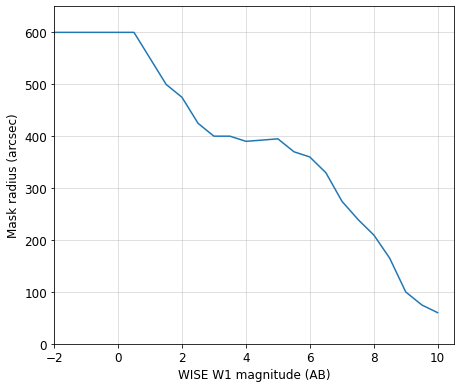

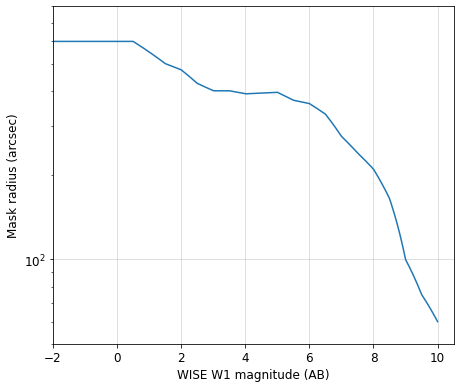

In [4]:
w1_plot = np.linspace(-2, 10, 1000)
plt.figure(figsize=(6.5, 5.5))
plt.plot(w1_plot, wise_radius(w1_plot))
plt.axis([-2, 10.5, 0, 650])
plt.xlabel('WISE W1 magnitude (AB)')
plt.ylabel('Mask radius (arcsec)')
plt.grid(alpha=0.5)
plt.tight_layout()
# plt.savefig('/Users/rongpu/git/desi-targets/lrg_paper/figures/wise_mask_radius_vs_magnitude.pdf')
plt.show()

w1_plot = np.linspace(-2, 10, 1000)
plt.figure(figsize=(6.5, 5.5))
plt.plot(w1_plot, wise_radius(w1_plot))
plt.axis([-2, 10.5, 50, 800])
plt.xlabel('WISE W1 magnitude (AB)')
plt.ylabel('Mask radius (arcsec)')
plt.grid(alpha=0.5)
plt.yscale('log')
plt.tight_layout()
plt.show()

In [5]:
# South
mags = np.array([4.0, 9.0, 10.0, 10.5, 11.5, 12.0, 12.5, 13.5, 14.0, 14.5, 15.0, 15.5, 16.0, 17.0, 18.0])
radii = np.array([429.18637985, 80.95037032, 57.98737129, 36.80882682,
        26.36735446, 25.29190318, 21.40616169, 15.33392671,
        13.74150366, 13.56870306, 12.03092488, 11.10823009,
         9.79334208, 7.01528803, 5.02527796])
log_radii = np.log10(radii)
gaia_radius_log_south = interp1d(mags, log_radii, bounds_error=False, fill_value='extrapolate')
gaia_radius_south = lambda mags: 10**gaia_radius_log_south(mags)

# North
mags = np.array([4.0, 9.0, 10.0, 10.5, 11.0, 11.5, 12.0, 12.5, 13.0, 13.5, 14.0, 14.5, 15.0, 15.5, 16.0, 17.0, 18.0])
radii = np.array([429.18637985, 80.95037032, 60., 60.,
        60., 47.46123803, 38.68173428, 32.73883553,
        27.70897871, 23.45188791, 19.84883862, 16.79934664,
        13.67150555, 11.57107301, 7.83467367, 5.61223042,
         4.02022236])
log_radii = np.log10(radii)
gaia_radius_log_north = interp1d(mags, log_radii, bounds_error=False, fill_value='extrapolate')
gaia_radius_north = lambda mags: 10**gaia_radius_log_north(mags)

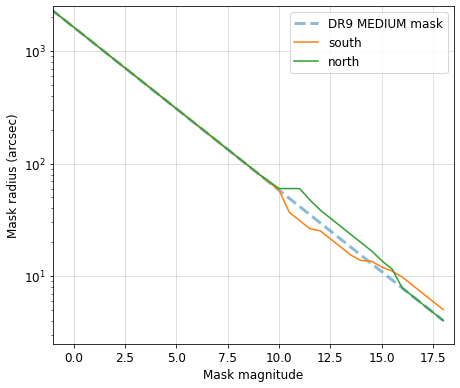

In [6]:
mags_plot = np.linspace(-2, 18, 1000)
dr9_radius = 1630 * 1.396**(-mags_plot)

plt.figure(figsize=(6.5, 5.5))
plt.plot(mags_plot, dr9_radius, label='DR9 MEDIUM mask', lw=3, ls='--', alpha=0.5)
plt.plot(mags_plot, gaia_radius_south(mags_plot), label='south')
plt.plot(mags_plot, gaia_radius_north(mags_plot), label='north')
plt.yscale('log')
plt.grid(alpha=0.5)
plt.xlabel('Mask magnitude')
plt.ylabel('Mask radius (arcsec)')
plt.axis([-1, 18.5, 2.5, 2500])
plt.legend()
plt.tight_layout()
# plt.savefig('/Users/rongpu/git/desi-targets/lrg_paper/figures/gaia_mask_radius_vs_magnitude.pdf')
plt.show()